In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('ushape.csv')

In [7]:
df = pd.read_csv("ushape.csv", header=None)

In [8]:
df.columns = ['x', 'y', 'class']

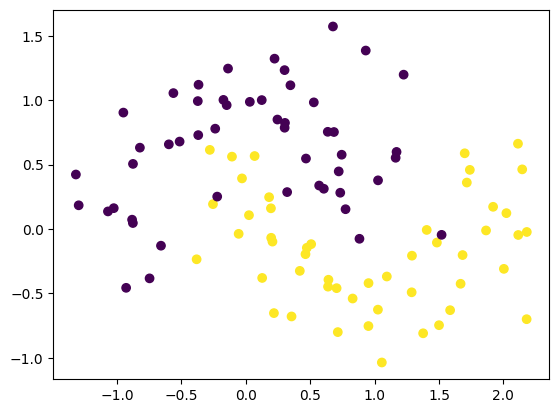

In [10]:
plt.scatter(df['x'],df['y'],c=df['class'])

In [11]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [12]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [13]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2,kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(1,activation='sigmoid'))#kernel-initializer will automatically glorat_uniform as he_normal is for relu

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.get_weights()

[array([[-0.5859072 ,  0.25400037,  0.16955042, -0.5297026 , -0.04844354,
          1.7511157 ,  0.6838975 ,  0.14606668, -0.24312645, -0.5818839 ],
        [-1.1322592 , -0.8112111 ,  0.4894879 , -1.1107689 , -0.31526825,
         -0.16425952,  1.630384  , -0.17546287, -0.1168211 , -0.4887047 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.24081704, -0.86721045,  0.6303216 , -0.02114735,  0.18324852,
         -0.09231718,  0.19080342,  0.44847596,  0.40309083,  0.5545988 ],
        [ 0.3594511 , -0.6104029 , -0.02145281, -0.08541986,  0.20822278,
          0.46216342,  0.8979002 , -0.3717673 , -0.07794941, -0.06349187],
        [-0.2113979 ,  0.92588574, -0.7292757 , -0.22012931,  0.8180158 ,
         -0.36459577, -0.74691355, -0.69384086,  0.10838909, -0.01616214],
        [ 0.24999724,  0.69106513, -0.25213876, -0.03621912, -0.5868748 ,
         -0.30795258, -0.7565758 , -0.09255987,  0.12562536, -0.05161127],
        [ 0.38370

In [15]:
initial_weights = model.get_weights()

In [16]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [17]:
model.set_weights(initial_weights)

In [18]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [19]:
model.get_weights()

[array([[-1.1914965 , -0.584059  , -1.2166471 , -0.22404334,  0.8137553 ,
         -0.75885266, -0.5829967 , -1.8825119 , -0.74550235,  1.4086185 ],
        [-0.3405776 , -0.32588726, -0.09885771, -0.1059086 , -0.8964006 ,
         -0.56923634,  1.1513734 , -1.6887223 ,  0.46618423, -0.38749084]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.21187755,  0.51751447, -0.04396994,  0.3538235 , -0.54392546,
          0.06569135, -0.19367884, -0.86007637,  0.21745422,  0.18343922],
        [-0.13083372, -0.19075072,  0.07243929, -0.08352825,  0.23181432,
          0.04836843,  0.42488563, -0.09858375, -0.06448915, -0.44111082],
        [ 0.4282413 ,  0.25811446, -0.2966102 ,  0.12437395, -0.2566895 ,
          0.73085004, -0.04945583, -0.39938062,  0.13945106,  0.21295656],
        [ 0.12414818,  0.05296456,  0.19128503, -0.5200507 ,  0.2599456 ,
         -0.22671422,  0.10399219, -0.0019996 ,  0.46569988,  0.17224061],
        [-0.10254

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


<Axes: >

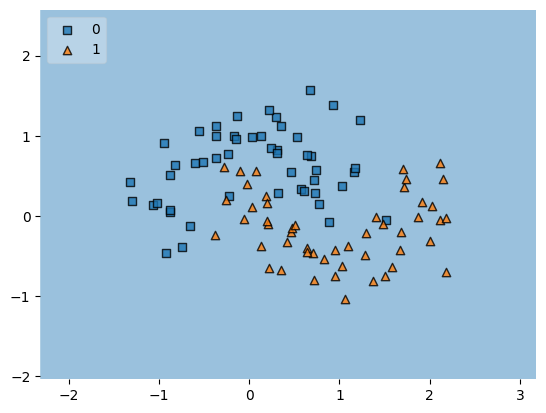

In [20]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)